In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print('(Rows, Columns):', df.shape)
print('==='*10)
df.info()

(Rows, Columns): (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
# Checking for duplicate rows
print('Duplicate rows:', df.duplicated().sum())
print('==='*10)
df.describe()

Duplicate rows: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Checking how balanced the target column is

In [5]:
df.Outcome.value_counts(normalize=True)     # diabetes prevalance

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

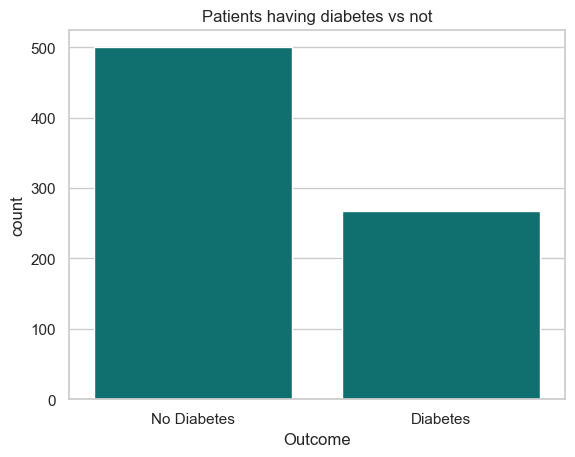

In [6]:
sns.countplot(data=df, x="Outcome", color='teal')
plt.title("Patients having diabetes vs not")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.show()

## Tackling missing values:
Diagnostic features like Glucose, BloodPressure, SkinThickness, Insulin, and BMI can never be zeros when the patient is alive - these zeros are actually missing or unrecorded values.

In [7]:
missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in missing_cols:
    n_zeros = (df[col] == 0).sum()
    pct_zeros = n_zeros / len(df) *100
    print(f'{col}: {n_zeros} zeros ({pct_zeros:.1f}% of the data)')

Glucose: 5 zeros (0.7% of the data)
BloodPressure: 35 zeros (4.6% of the data)
SkinThickness: 227 zeros (29.6% of the data)
Insulin: 374 zeros (48.7% of the data)
BMI: 11 zeros (1.4% of the data)


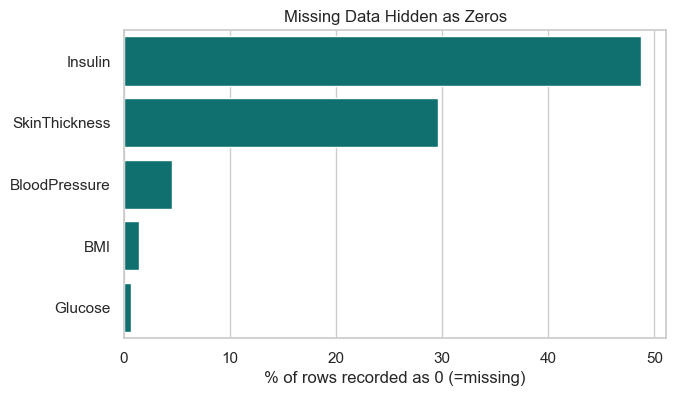

In [8]:
# Calculate missing percentages
missing_pct = [(df[c] == 0).mean() * 100 for c in missing_cols]

# Sort by descending values
sorted_pairs = sorted(zip(missing_pct, missing_cols), reverse=True)
sorted_pct, sorted_cols = zip(*sorted_pairs)

# Plot
plt.figure(figsize=(7, 4))
sns.barplot(x=sorted_pct, y=sorted_cols, color = 'teal')
plt.xlabel('% of rows recorded as 0 (=missing)')
plt.title("Missing Data Hidden as Zeros")
plt.show()

**Notice**: Insulin (about 49%) and SkinThickness (about 30%) are missing a large chunk of data. This prevents deleting the rows, which will result in huge data loss. The missing values need to be imputed.

## Splitting the dataset into Train and Test sets:
Cleaning the *whole* dataset first and splitting it afterward will result in information from the result leaking into the cleaning statistics.

In [9]:
feature_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

x = df[feature_cols].copy()
y = df['Outcome'].copy()

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, stratify = y, random_state = 42)

print("Train size:", x_train.shape)
print("Test size:", x_test.shape)

Train size: (614, 8)
Test size: (154, 8)


## Replacing the zeros with null

In [10]:
for col in missing_cols:
    x_train[col] = x_train[col].replace(0, np.nan)
    x_test[col] = x_test[col].replace(0, np.nan)

x_train[missing_cols].isna().sum()

Glucose            4
BloodPressure     23
SkinThickness    175
Insulin          290
BMI                9
dtype: int64

## Adding originally missing flags

This is to track the originally missing values so that the filled-in values don't get treated as outliers

In [11]:
train_was_missing = x_train[missing_cols].isna()

# Adding flag columns only for the two columns with maximum missing data
x_train["Insulin_missing"] = x_train["Insulin"].isna().astype(int)
x_test["Insulin_missing"] = x_test["Insulin"].isna().astype(int)

x_train["SkinThickness_missing"] = x_train["SkinThickness"].isna().astype(int)
x_test["SkinThickness_missing"] = x_test["SkinThickness"].isna().astype(int)

## Imputing the missing values

It's better to use the Median instead of the mean as colummns like Insulin are heavily skewed — a few very high values will pull the mean up, but median stays close to a typical patient. 

The median will be calculated using training data only, and then applied to the test set too.

In [12]:
imputer = SimpleImputer(strategy='median')

x_train[missing_cols] = imputer.fit_transform(x_train[missing_cols])
x_test[missing_cols] = imputer.fit_transform(x_test[missing_cols])

# The median values that were used:
dict(zip(missing_cols, imputer.statistics_))

{'Glucose': 118.0,
 'BloodPressure': 72.0,
 'SkinThickness': 29.0,
 'Insulin': 123.5,
 'BMI': 31.8}

## Handling Outliers

The standard IQR method can be used to find unusually high or low values and cap them to a reasonable range.

Calculating the IQR after filling in missing values will skew the IQR. So the IQR should be calculated using the original values only (using the missing flag)

In [13]:
def get_iqr_bounds(train_series, was_missing_mask):
    #Calculate IQR bounds using only the originally observed (non-imputed) values.
    real_values = train_series[~was_missing_mask]  # tilde '~' flips the boolean values, keeping the original missing values only.
    q1, q3 = real_values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

In [14]:
outlier_counts = {}  # will hold {column_name: number_of_rows_capped}

for col in feature_cols:
    if col in missing_cols:
        lower, upper = get_iqr_bounds(x_train[col], train_was_missing[col])
    else:
        q1, q3 = x_train[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    n_capped = ((x_train[col] < lower) | (x_train[col] > upper)).sum()
    print(f"{col}: capping to [{lower:.1f}, {upper:.1f}] -> {n_capped} rows affected")

    outlier_counts[col] = n_capped

    x_train[col] = x_train[col].clip(lower, upper)
    x_test[col] = x_test[col].clip(lower, upper)


Pregnancies: capping to [-6.5, 13.5] -> 2 rows affected
Glucose: capping to [36.4, 203.4] -> 0 rows affected
BloodPressure: capping to [40.0, 104.0] -> 13 rows affected
SkinThickness: capping to [-1.5, 58.5] -> 2 rows affected
Insulin: capping to [-85.2, 344.8] -> 17 rows affected
BMI: capping to [14.1, 50.1] -> 6 rows affected
DiabetesPedigreeFunction: capping to [-0.3, 1.2] -> 19 rows affected
Age: capping to [-1.5, 66.5] -> 6 rows affected


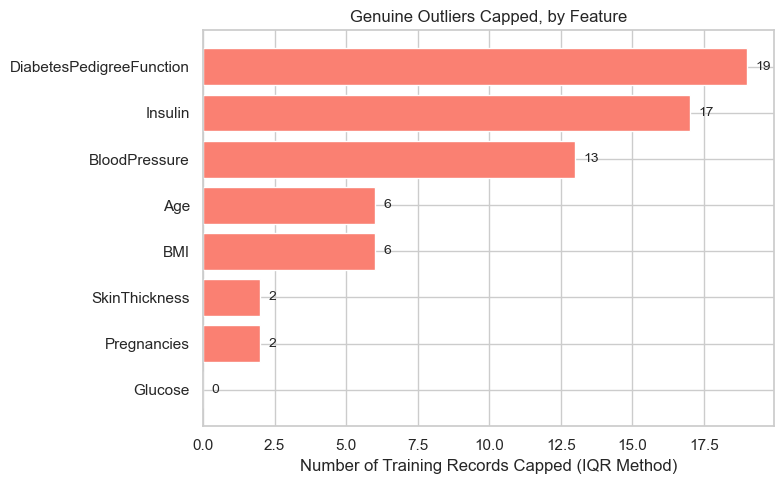

In [41]:
# Turn the outlier_counts dict into a horizontal bar chart, sorted smallest -> largest
counts_series = pd.Series(outlier_counts).sort_values()

plt.figure(figsize=(8, 5))
bars = plt.barh(counts_series.index, counts_series.values, color="salmon")

# Add the count as a text label at the end of each bar
for bar, value in zip(bars, counts_series.values):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
              str(value), va="center", fontsize=10)

plt.xlabel("Number of Training Records Capped (IQR Method)")
plt.title("Genuine Outliers Capped, by Feature")
plt.tight_layout()
plt.show()


## Adding visualizations to the cleaned data

In [16]:
train_df = x_train.copy()
train_df['Outcome'] = y_train.values

train_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Insulin_missing,SkinThickness_missing,Outcome
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.812704,121.671010,72.107492,28.973941,133.854642,32.387622,0.466070,33.319218,0.472313,0.285016,0.348534
std,3.291930,30.003794,11.788989,8.505548,61.822057,6.617477,0.290059,11.681606,0.499640,0.451790,0.476895
min,0.000000,56.000000,40.000000,7.000000,15.000000,18.200000,0.084000,21.000000,0.000000,0.000000,0.000000
25%,1.000000,99.000000,64.000000,25.000000,120.000000,27.625000,0.245000,24.000000,0.000000,0.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.400000,0.382500,29.000000,0.000000,0.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,130.000000,36.500000,0.639250,41.000000,1.000000,1.000000,1.000000
max,13.500000,199.000000,104.000000,58.500000,344.750000,50.100000,1.230625,66.500000,1.000000,1.000000,1.000000


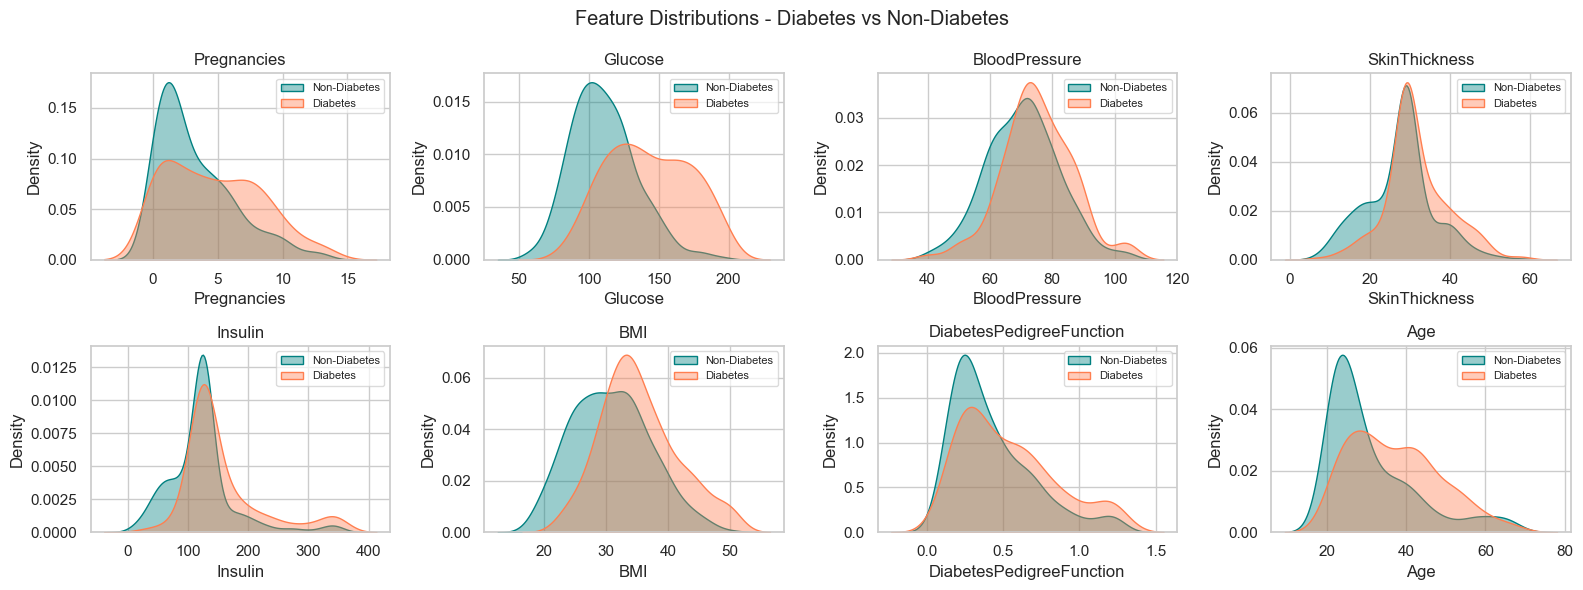

In [17]:
plt.figure(figsize=(16, 6))

# Loop through each feature column
for i, col in enumerate(feature_cols, 1):
    plt.subplot(2, 4, i)  # adjust grid size depending on number of features
    
    # Plot non-diabetes (assuming target column is 'Outcome' with 0 = non-diabetes, 1 = diabetes)
    sns.kdeplot(data=train_df[train_df['Outcome'] == 0], x=col, fill=True, color="teal", alpha=0.4, label="Non-Diabetes")
    
    # Plot diabetes
    sns.kdeplot(data=train_df[train_df['Outcome'] == 1], x=col, fill=True, color="coral", alpha=0.4, label="Diabetes")
    
    plt.title(col)
    plt.legend(prop={'size': 8}, framealpha=0.7)

plt.suptitle("Feature Distributions - Diabetes vs Non-Diabetes")
plt.tight_layout()
plt.show()

In [18]:
palette=sns.color_palette("light:#4A9", as_cmap=True)

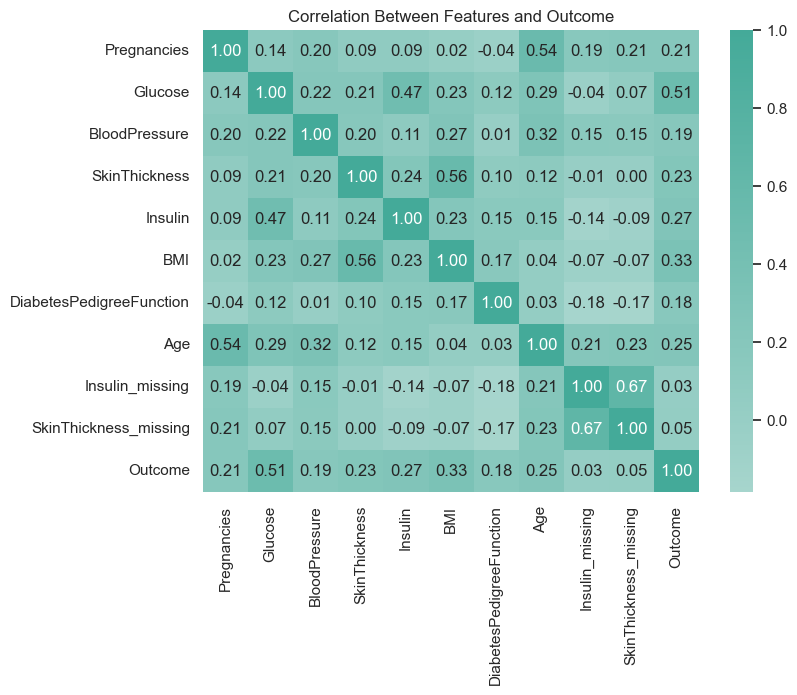

In [19]:
# Correlation Heatmap

plt.figure(figsize = (8,6))
sns.heatmap(train_df.corr(), annot=True, fmt=".2f", cmap=palette, center = 0)
plt.title("Correlation Between Features and Outcome")
plt.show()

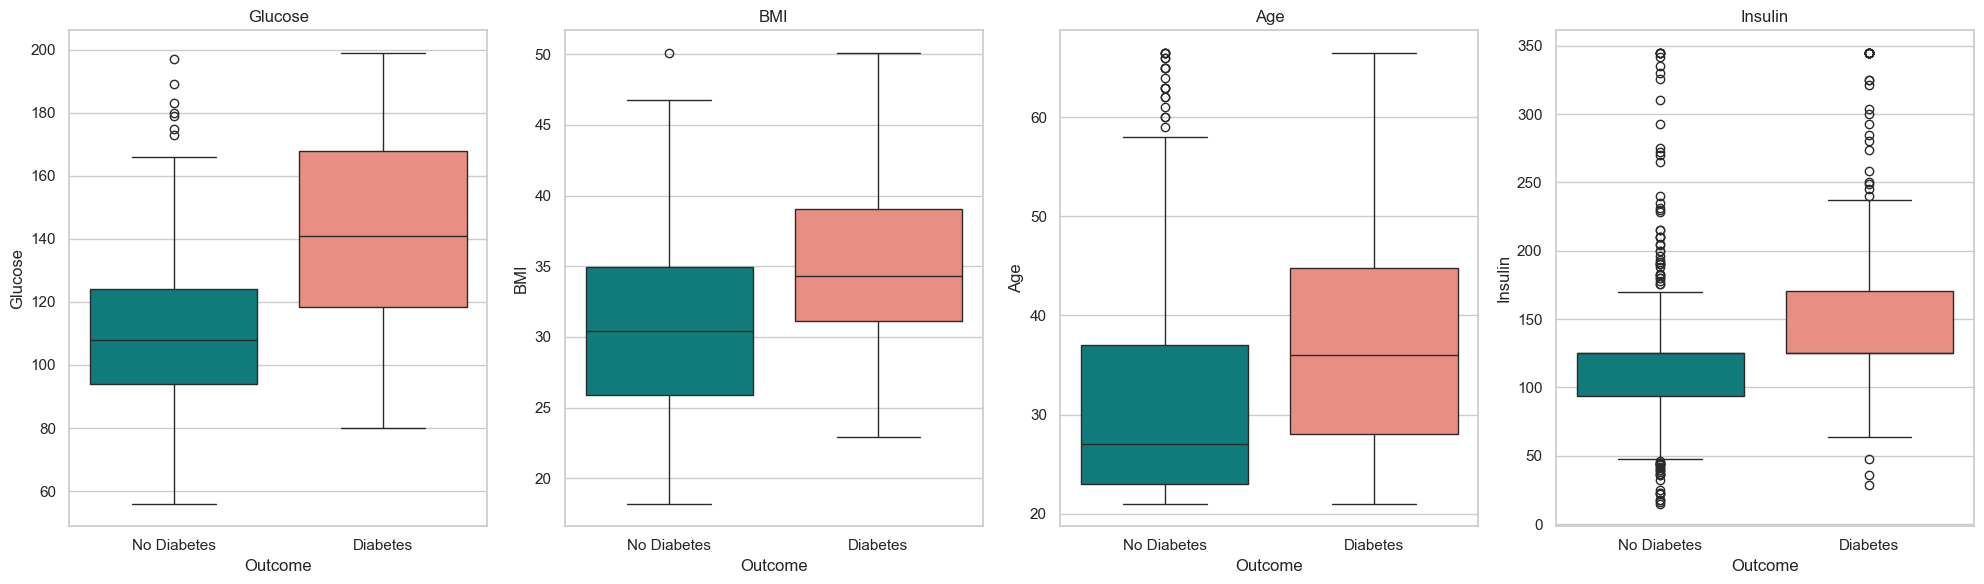

In [40]:
# Boxplots for the important diagnostic features

key_features = ["Glucose", "BMI", "Age", "Insulin"]
custom_palette = {0: "darkcyan", 1: "salmon"} 

fig, axes = plt.subplots(1, 4, figsize=(20,6))
for ax, col in zip(axes, key_features):
    sns.boxplot(data=train_df, x="Outcome", y=col, hue="Outcome", palette=custom_palette, legend=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No Diabetes", "Diabetes"])
    ax.set_title(col)
plt.tight_layout()
plt.show()

`Glucose` and `BMI` show the clearest separation between patients with
and without diabetes

### Saving the clean data

In [21]:
test_df = x_test.copy()
test_df["Outcome"] = y_test.values

train_df.to_csv("C:/Users/Priyanshu/Projects/mentorminds/train_cleaned.csv", index=False)
test_df.to_csv("C:/Users/Priyanshu/Projects/mentorminds/test_cleaned.csv", index=False)

print("Saved train_cleaned.csv:", train_df.shape)
print("Saved test_cleaned.csv:", test_df.shape)


Saved train_cleaned.csv: (614, 11)
Saved test_cleaned.csv: (154, 11)


## Summary

- Loaded 768 patient records, 8 features, target is imbalanced (65% / 35%).
- Found that 5 columns used `0` to mean "missing" — treated these as missing, not outliers.
- Split into train/test **before** cleaning, to avoid leaking test information.
- Filled missing values using the training median, and added "was missing" flag columns
  for `Insulin` and `SkinThickness`.
- Capped genuine outliers using the IQR method, calculated from real (non-imputed) values
  only.
- Explored the cleaned data with distribution plots, a correlation heatmap, and boxplots.
- Saved `train_cleaned.csv` and `test_cleaned.csv` for use in feature engineering
  and modeling.
